# Longitudinal normative modelling

A normative model tells you where a single measurement sits relative to a reference population (a z-score). With **two or more visits per person**, we can go further and ask:

> Did this person change *more than expected* between visits?

This notebook shows the two scores PCNtoolkit provides for that question:

- **z-diff**
- **z-gain**

We use a cross-sectional dataset (`fcon1000`) to build the reference model, and a longitudinal dataset (`LNM_data`, two visits per subject) to score change over time.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pcntoolkit import (
    BLR,
    NormData,
    NormativeModel,
    ZDiffScore,
    ZGainScore,
 )
from pcntoolkit.math_functions.basis_function import (
    BsplineBasisFunction,
 )


def find_data_dir():
    """Locate the example-data folder by searching upward."""
    # Check the current folder and each parent folder in turn.
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "pcntoolkit_resources" / "data"
        # Stop once both files needed by this notebook are found.
        if (
            (candidate / "fcon1000.csv").exists()
            and (candidate / "LNM_data.csv").exists()
        ):
            return candidate
    raise FileNotFoundError(
        "Could not find pcntoolkit_resources/data with "
        "fcon1000.csv and LNM_data.csv"
    )


data_dir = find_data_dir()


def tidy_region_names(df):
    """Use one consistent naming for cortical-thickness columns. Makes sure
    that both datasets have the same column names for the same regions."""
    return df.rename(
        columns={
            c: c.replace("&", "_and_").replace(
                "_thickness", ""
            )
            for c in df.columns
        }
    )


# Choose two cortical-thickness regions
response_vars = ["lh_G_front_middle", "lh_G_and_S_frontomargin"]

## 1. Build the reference model

We fit a normative model of cortical thickness against age on the cross-sectional reference data.

In [ ]:
# Load the cross-sectional reference cohort used to fit the model.
reference_df = tidy_region_names(pd.read_csv(data_dir / "fcon1000.csv"))

reference_data = NormData.from_dataframe(
    name="reference",
    dataframe=reference_df,
    covariates=["age"],
    batch_effects=None,
    response_vars=response_vars,
    subject_ids="sub_id",
)

model = NormativeModel(
    BLR(
        basis_function_mean=BsplineBasisFunction(degree=3, nknots=5),
        warp_name="warpsinharcsinh",
    ),
    inscaler="standardize",
    outscaler="standardize",
    savemodel=False,
    saveresults=False,
)

model.fit(reference_data)

Process: 33132 - 2026-06-09 10:41:16 - Dataset "reference" created.
    - 1078 observations
    - 1078 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 33132 - 2026-06-09 10:41:16 - Fitting models on 2 response variables.
Process: 33132 - 2026-06-09 10:41:16 - Fitting model for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Fitting model for lh_G_and_S_frontomargin.


Process: 33132 - 2026-06-09 10:41:17 - Making predictions on 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing z-scores for 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing z-scores for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:17 - Computing log-probabilities for 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing log-probabilities for 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing log-probabilities for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Computing log-probabilities for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:17 - Co

Process: 33132 - 2026-06-09 10:41:17 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Computing centiles for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:17 - Harmonizing data on 2 response variables.
Process: 33132 - 2026-06-09 10:41:17 - Harmonizing data for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:17 - Harmonizing data for lh_G_and_S_frontomargin.


## 2. Load the longitudinal data and predict z-scores

Each subject in `LNM_data` has two visits. We load it, line up its column names with the reference data, and use the model to predict a z-score for every visit.

In [ ]:
# Load the longitudinal cohort that has repeated visits per subject.
longitudinal_df = tidy_region_names(pd.read_csv(data_dir / "LNM_data.csv"))

longitudinal_data = NormData.from_dataframe(
    name="longitudinal",
    dataframe=longitudinal_df,
    covariates=["age"],
    batch_effects=None,
    response_vars=response_vars,
    subject_ids="sub_id",
)

# Predict cross-sectional z-scores for every visit in the cohort.
longitudinal_data = model.predict(longitudinal_data)

Process: 33132 - 2026-06-09 10:41:18 - Dataset "longitudinal" created.
    - 330 observations
    - 165 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 33132 - 2026-06-09 10:41:18 - Making predictions on 2 response variables.
Process: 33132 - 2026-06-09 10:41:18 - Computing z-scores for 2 response variables.
Process: 33132 - 2026-06-09 10:41:18 - Computing z-scores for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:18 - Computing z-scores for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:18 - Computing centiles for 2 response variables.
Process: 33132 - 2026-06-09 10:41:18 - Computing centiles for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:18 - Computing centiles for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:18 - Computing log-probabilities for 2 response variables.
Process: 33132 - 2026-06-09 10:41:18 - Computing log-probabilities for 2 response variables.
Proce

Process: 33132 - 2026-06-09 10:41:19 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 2 response variables
    - 1 batch effects:
    	dummy_batch_effect (1)
    
Process: 33132 - 2026-06-09 10:41:19 - Computing centiles for 2 response variables.
Process: 33132 - 2026-06-09 10:41:19 - Computing centiles for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:19 - Computing centiles for lh_G_and_S_frontomargin.
Process: 33132 - 2026-06-09 10:41:19 - Harmonizing data on 2 response variables.
Process: 33132 - 2026-06-09 10:41:19 - Harmonizing data for lh_G_front_middle.
Process: 33132 - 2026-06-09 10:41:19 - Harmonizing data for lh_G_and_S_frontomargin.


## 3. z-diff: change between two visits
Values near 0 are typical; large positive or negative values indicate unusual change.

In [ ]:
zdiff = ZDiffScore(
    normative_model=model,
    reference_data=longitudinal_data,
    subject_id_col="sub_id",
)

# In this toy example, the score data are the same as the reference data. We
# could also split use score data = patients and 
# reference data = healthy controls.
zdiff_scores = zdiff.score(
    score_data = longitudinal_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Show the first few subject-level z-diff scores.
zdiff_scores.to_dataframe(name="z_diff").unstack("response_vars").head()

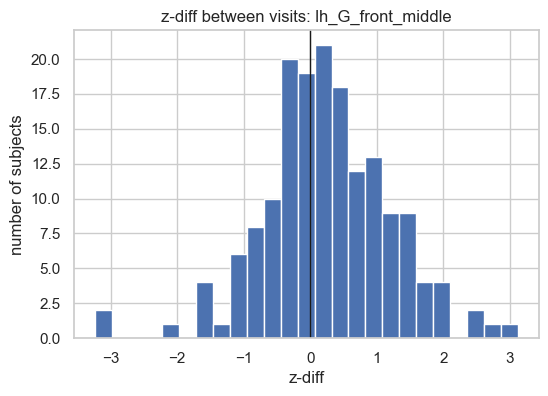

In [ ]:
# Pick one region
region = response_vars[0]

# Plot the distribution of z-diff values across subjects.
plt.figure(figsize=(6, 4))
plt.hist(
    zdiff_scores.sel(response_vars=region).values,
    bins=25,
    color="#4c72b0",
    edgecolor="white",
)

# Mark zero, which corresponds to typical change.
plt.axvline(0, color="k", lw=1)
plt.xlabel("z-diff")
plt.ylabel("number of subjects")
plt.title(f"z-diff between visits: {region}")
plt.show()

## 4a. z-gain

`ZGainScore` asks whether a subject's z-score at the later visit is surprising given their earlier visit. It relies on how strongly z-scores are correlated across ages, which it estimates as a **correlation matrix**.

In [ ]:
zgain = ZGainScore(
    normative_model=model,
    reference_data=longitudinal_data,
    subject_id_col="sub_id",
    bandwidth=5,
    covariate="age",
)

# In this toy example, the score data are the same as the reference data. We
# could also split use score data = patients and 
# reference data = healthy controls.
zgain_scores = zgain.score(
    score_data=longitudinal_data,
    subject_id_col="sub_id",
    timepoint_col="visit",
)

# Show the first few subject-level z-gain scores.
zgain_scores.to_dataframe(name="z_gain").unstack("response_vars").head()

# 4b Plot the correlation matrix

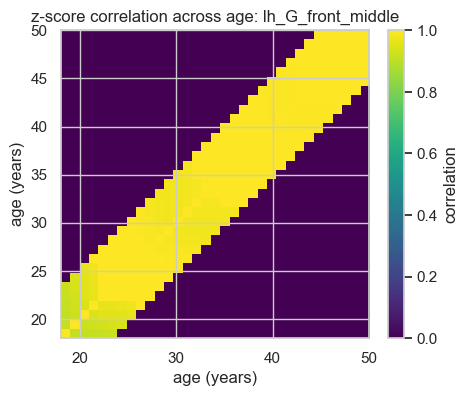

In [ ]:
# The learned correlation matrix is stored after z-gain is computed.
R = zgain.correlation_matrix.sel(response_vars=region)

# Read the integer ages used on both matrix axes.
ages = R["age_1"].values

# Keep only the age window that is well covered by the example data.
keep = (ages >= 18) & (ages <= 50)

# Display the age-to-age z-score correlation matrix as a heatmap.
plt.figure(figsize=(5, 4))
plt.imshow(
    R.values[np.ix_(keep, keep)],
    origin="lower",
    extent=[
        ages[keep].min(),
        ages[keep].max(),
        ages[keep].min(),
        ages[keep].max(),
    ],
    vmin=0,
    vmax=1,
    cmap="viridis",
)
plt.colorbar(label="correlation")
plt.xlabel("age (years)")
plt.ylabel("age (years)")
plt.title(f"z-score correlation across age: {region}")
plt.show()

## 5. Are the results as expected?

For this reference population we expect:

- z-diff scores centred near 0 (most people change a typical amount),
- z-diff and z-gain to broadly **agree** on who shows unusual change, since both measure the same thing on this two-visit data.

z-diff: mean = 0.23, sd = 0.97
z-gain: mean = 0.36, sd = 1.74
agreement (same direction): 98%


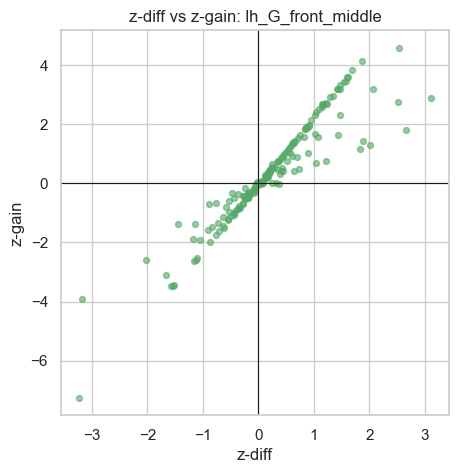

In [ ]:
# Read the two longitudinal scores for one region.
zd = zdiff_scores.sel(response_vars=region).values
zg = zgain_scores.sel(response_vars=region).values

# Keep only subjects with finite values in both scores.
ok = np.isfinite(zd) & np.isfinite(zg)

# Summarise the location and spread of the two score distributions.
print(f"z-diff: mean = {zd[ok].mean():.2f}, sd = {zd[ok].std():.2f}")
print(f"z-gain: mean = {zg[ok].mean():.2f}, sd = {zg[ok].std():.2f}")
print(
    "agreement (same direction): "
    f"{np.mean(np.sign(zd[ok]) == np.sign(zg[ok])):.0%}"
)

# Plot the subject-level agreement between z-diff and z-gain.
plt.figure(figsize=(5, 5))
plt.scatter(zd[ok], zg[ok], s=18, alpha=0.6, color="#55a868")
plt.axhline(0, color="k", lw=0.8)
plt.axvline(0, color="k", lw=0.8)
plt.xlabel("z-diff")
plt.ylabel("z-gain")
plt.title(f"z-diff vs z-gain: {region}")
plt.show()

## Choosing between z-diff and z-gain
 
| You have…                              | Use          |
|----------------------------------------|--------------|
| Two timepoints, BLR model              | `ZDiffScore` — simpler, scalar variance estimate |
| Two timepoints, want thrive lines      | `ZGainScore` |
| Three or more timepoints               | `ZGainScore` (z-diff doesn't generalise) |
| Want to forecast future visits         | `ZGainScore.conditional_forecast()` |
 

A large positive or negative score flags a subject whose change over time is unusual compared with the reference population -- could be a useful metric to find atypical trajectories in clinical populations.